In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [3]:

ckd=pd.read_csv("C:/Users/ameli/Downloads/kidney_disease.csv")

ckd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

Some Comments about attributes: Gender would have been a good feature to include because the normal range for sc varies a bit for M/F. Hemoglobin and anemia are redundant, one should be eliminated. Bp, blood pressure, and hypertension are redundant, one should be eliminated. Also, some patients with low hemoglobin were incorrectly assigned 'no anemia'. Specific gravity contributed no info because Al is measured in units 0,1,2,3,4,5. The column should have been eliminated from the dataset.

In [4]:
ckd['classification'].value_counts()['ckd']

248

In [5]:
ckd['classification'].value_counts()['notckd']

150

In [6]:
ckd['classification'].value_counts()['ckd\t']

2

In [7]:
ckd[ckd['classification']=='ckd\t'].index

Index([37, 230], dtype='int64')

In [8]:
ckd['classification']=ckd['classification'].str.replace('ckd\t', 'ckd')

In [9]:
ckd['classification'].value_counts()['ckd']

250

In [75]:
#Serum Creatinine measures kidney function. The normal range of Serum Creatinine is 0.20-1.10, 0.8-1.1 are considered high 
#normal, and 1.1-1.2 is viewed as borderline.(Gender should have been included as a feature because the normal range for females
#is a bit less, 0.5 -1.0). >=1.3 indiactes kidney disease.
# We want to know how many of the 400 patients had Serum Creatinine >=1.3 and were they all classified as having CKD(Chronic 
#Kidney Disease)

print((ckd['sc'] >=1.3).sum())
((ckd['sc'] >=1.3) & (ckd['classification']=='notckd')).sum()

193


0

Thus all 193 patients who had sc(=Serum Creatinine) values >=1.3 were classified in the dataset as having 'ckd' =(Chronic kidney disease).

In [93]:
dn=df[df['sc'].isnull()]
len(dn)

17

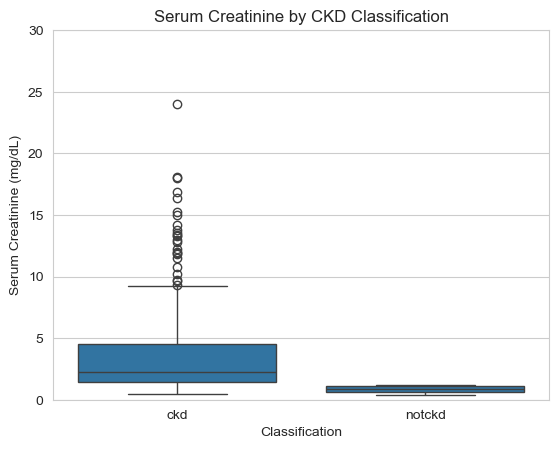

In [43]:
sns.boxplot(x='classification', y='sc', data=ckd)
plt.ylim(0, 30)  # Set y-axis limits
plt.title('Serum Creatinine by CKD Classification')
plt.ylabel('Serum Creatinine (mg/dL)')
plt.xlabel('Classification')
plt.show()

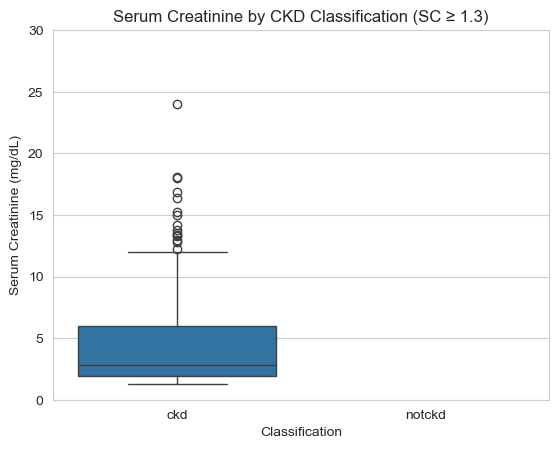

In [44]:
filtered_ckd = ckd[ckd['sc'] >= 1.3]


sns.boxplot(x='classification', y='sc', data=filtered_ckd, order=['ckd', 'notckd'])
plt.ylim(0, 30) 
plt.title('Serum Creatinine by CKD Classification (SC ≥ 1.3)')
plt.ylabel('Serum Creatinine (mg/dL)')
plt.xlabel('Classification')
plt.show()

Serum Creatinine alone correctly classifies 88% of the 383 patients in the dataset for which there are Serum Creatinine values (and it correctly classifies 100% of the patients with serum creatinine values >= 1.3) 

It is established in nephrology that Urine Albumin is another independent indicator of Kidney disease. (In this dataset Al is measured in positive integers and so) Al > 0 means kidney disease. The dataset was consistent with this established fact in nephrology: Each patient with albumin(defined in this dataset as >=1 g/g) in their urine, was classified as having CKD (=Chronic Kidney Disease). Below it is shown that the two features, Serum Creatinine and Urine Albumin alone can account for the accurate CKD classification of 93% of the 400 patients in the dataset.

In [ ]:
Although, kidney disease often has no symptoms until it is very advanced, there are two
symptoms that sometimes occur: hypertension and/or swollen ankles. If a patient has either of those along with high normal or
borderline Serum Creatinine they will be suspicious for kidney disease and a biopsy will be done. If we add these two features, 
htn and pe, the accuracy of determining CKD classification goes up to 95%.                                                                                                                          
                                                                                                                              

Heart disease and diabetes are two conditions that increase the risk of developing kidney disease. 

In [23]:
scr_al_ckd =ckd[['sc','al','classification']]

In [24]:
((ckd['al']>0) & (ckd['classification']=='notckd')).sum()

0

In [59]:
scr_al_ckd.head(5)

,sc,al,classification,new column
0,1.2,1.0,ckd,ckd
1,0.8,4.0,ckd,ckd
2,1.8,2.0,ckd,ckd
3,3.8,4.0,ckd,ckd
4,1.4,2.0,ckd,ckd


In [47]:
def twofeat(sc, al):
    # Check if sc is not NaN and >= 1.3
    if pd.notna(sc) and sc >= 1.3:
        return 'ckd'
    # Check if al is not NaN and > 0
    if pd.notna(al) and al > 0:
        return 'ckd'
    else:
        return 'notckd'


     

In [91]:
scr_al_ckd['new column'] = scr_al_ckd.apply(lambda row:twofeat(row.iloc[0],row.iloc[1]), axis=1)
print(scr_al_ckd.head(5))
print(scr_al_ckd.shape)
print(scr_al_ckd.iloc[0,1])
print(scr_al_ckd.info())

    sc   al classification new column
0  1.2  1.0            ckd        ckd
1  0.8  4.0            ckd        ckd
2  1.8  2.0            ckd        ckd
3  3.8  4.0            ckd        ckd
4  1.4  2.0            ckd        ckd
(400, 4)
1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sc              383 non-null    float64
 1   al              354 non-null    float64
 2   classification  400 non-null    object 
 3   new column      400 non-null    object 
dtypes: float64(2), object(2)
memory usage: 12.6+ KB
None


C:\Users\ameli\AppData\Local\Temp\ipykernel_15716\701828622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scr_al_ckd['new column'] = scr_al_ckd.apply(lambda row:twofeat(row.iloc[0],row.iloc[1]), axis=1)


In [51]:
num_different =(scr_al_ckd.iloc[ :,2] != scr_al_ckd.iloc[ :,3]).sum()
print(f"Number of rows where classification ≠ new column: {num_different}")

Number of rows where classification ≠ new column: 28


In [76]:
total = 0
for i in range(400):
    if scr_al_ckd.iloc[i, 2] != scr_al_ckd.iloc[i, 3]:
        total = total + 1
        
print(total)        

28


Thus the two features alone, Serum Creatinine and Urine Albumin, can account for the correct CKD classification of 93% = (400-28)/400 of the 400 patients in the dataset.

In [77]:
def f(i):
    if scr_al_ckd.iloc[i,2] ==scr_al_ckd.iloc[i,3]:
        return 1
    else:
        return 0

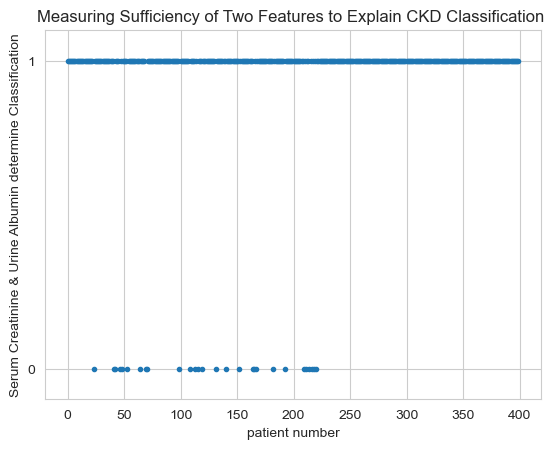

In [78]:

x = np.arange(0, 400)

y = [f(i) for i in x]

# Plot
plt.plot(x, y, linestyle='none', marker='o', markersize=3)
plt.xlabel('patient number')
plt.ylabel('Serum Creatinine & Urine Albumin determine Classification')
plt.title('Measuring Sufficiency of Two Features to Explain CKD Classification ')
plt.ylim(-0.1, 1.1)
plt.yticks([0, 1])
plt.grid(True)
plt.show()


In [83]:
sc_al_ckd_pe_htn =ckd[['sc','al','classification','pe','htn']]
sc_al_ckd_pe_htn.head()

,sc,al,classification,pe,htn
0,1.2,1.0,ckd,no,yes
1,0.8,4.0,ckd,no,no
2,1.8,2.0,ckd,no,no
3,3.8,4.0,ckd,yes,yes
4,1.4,2.0,ckd,no,no


In [94]:
   
df=sc_al_ckd_pe_htn
dg=df[(df['classification']=='ckd') & (df['pe']=='yes') & ( (df['al']==0) & (df['sc']<1.3))]
print(dg)
print(len(dg))
dw = df[(df['classification']=='ckd') & (df['htn']=='yes') & ( (df['al']==0) & (df['sc']<1.3))]
print(dw)
print(len(dw))


      sc   al classification   pe  htn
41   0.7  0.0            ckd  yes   no
48   0.9  0.0            ckd  yes  yes
99   1.2  0.0            ckd  yes  yes
164  0.8  0.0            ckd  yes   no
4
     sc   al classification   pe  htn
42  1.0  0.0            ckd   no  yes
48  0.9  0.0            ckd  yes  yes
53  1.0  0.0            ckd   no  yes
70  0.7  0.0            ckd   no  yes
99  1.2  0.0            ckd  yes  yes
5
